In [10]:
# DATA PREPARATION & QUALITY CHECK

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\ayura\Downloads\E-commerce Customer Behavior - Sheet1.csv"
df = pd.read_csv(file_path)

df_clean = df.dropna().copy()

# Creating a new column to group ages into simple buckets (20-30, 31-40, etc.)
df_clean['Age Group'] = pd.cut(df_clean['Age'], bins=[20, 30, 40, 50], labels=['20-30', '31-40', '41-50'])

print("Data Validation Complete: Data is loaded, cleaned, and ready for analysis!")

Data Validation Complete: Data is loaded, cleaned, and ready for analysis!


Total Sales Distribution by Membership


,Membership Type,Total Spend
1,Gold,153403.9
2,Silver,87566.6
0,Bronze,54061.5


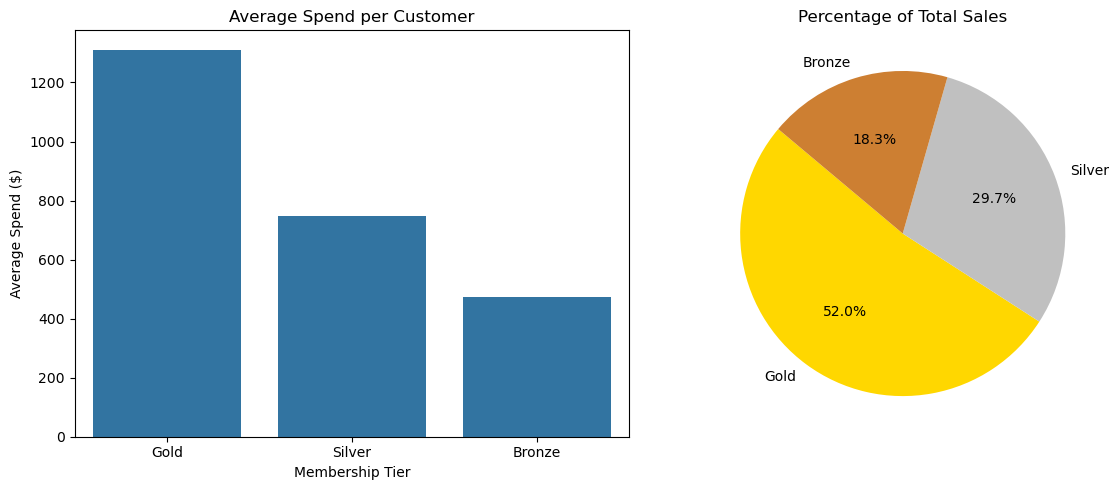

In [11]:
# Understanding the financial impact of the customer loyalty program.

spend_membership_avg = df_clean.groupby('Membership Type', observed=False)['Total Spend'].mean().reset_index()

spend_membership_total = df_clean.groupby('Membership Type', observed=False)['Total Spend'].sum().reset_index()

spend_membership_total['Membership Type'] = pd.Categorical(
    spend_membership_total['Membership Type'], 
    categories=['Gold', 'Silver', 'Bronze'], 
    ordered=True
)
spend_membership_total = spend_membership_total.sort_values('Membership Type')

print("Total Sales Distribution by Membership")
display(spend_membership_total.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=spend_membership_avg, x='Membership Type', y='Total Spend', order=['Gold', 'Silver', 'Bronze'], ax=axes[0])
axes[0].set_title('Average Spend per Customer')
axes[0].set_ylabel('Average Spend ($)')
axes[0].set_xlabel('Membership Tier')

tier_colors = ['#FFD700', '#C0C0C0', '#CD7F32'] 

axes[1].pie(spend_membership_total['Total Spend'], labels=spend_membership_total['Membership Type'], autopct='%1.1f%%', startangle=140, colors=tier_colors)
axes[1].set_title('Percentage of Total Sales')

plt.tight_layout()
plt.show()

Average Spend by City


,City,Total Spend
0,San Francisco,1459.77
1,New York,1165.04
2,Los Angeles,805.49
3,Miami,690.39
4,Chicago,499.88
5,Houston,447.65


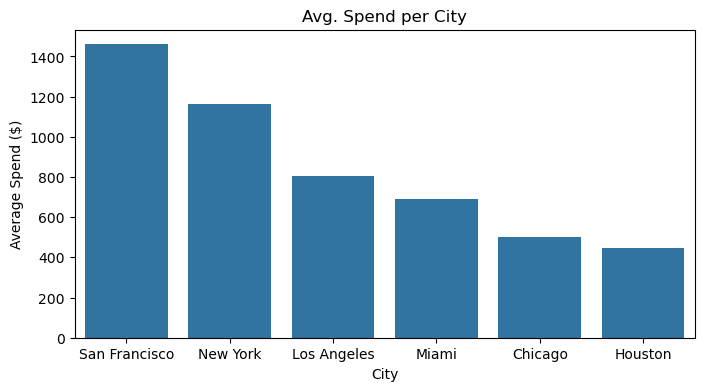

In [13]:
# Geographical Revenue Analysis

spend_city = df_clean.groupby('City')['Total Spend'].mean().sort_values(ascending=False).reset_index()
print("Average Spend by City")
display(spend_city.round(2))

plt.figure(figsize=(8, 4))
sns.barplot(data=spend_city, x='City', y='Total Spend')

plt.title('Avg. Spend per City')
plt.ylabel('Average Spend ($)')
plt.xlabel('City')
plt.show()

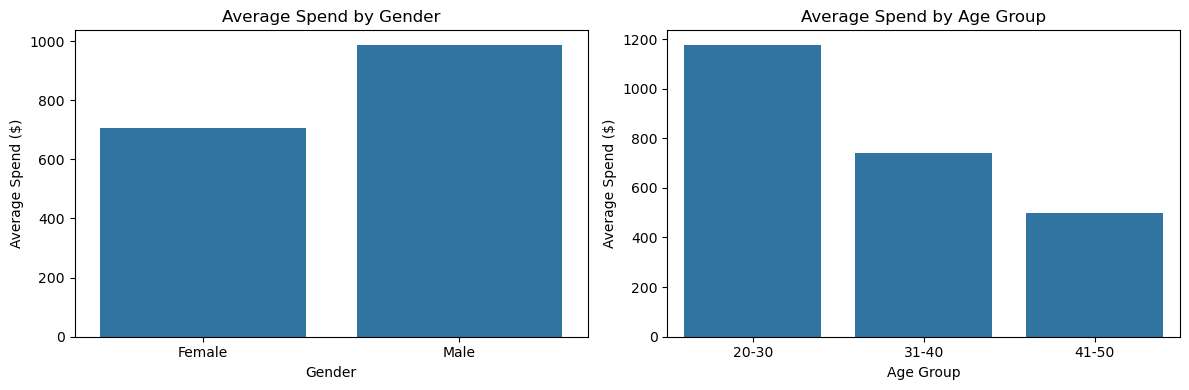

In [14]:
# Breaking down purchasing behavior by core demographics (Gender and Age)
spend_gender = df_clean.groupby('Gender')['Total Spend'].mean().reset_index()

spend_age = df_clean.groupby('Age Group', observed=False)['Total Spend'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(data=spend_gender, x='Gender', y='Total Spend', ax=axes[0])
axes[0].set_title('Average Spend by Gender')
axes[0].set_ylabel('Average Spend ($)')

sns.barplot(data=spend_age, x='Age Group', y='Total Spend', ax=axes[1])
axes[1].set_title('Average Spend by Age Group')
axes[1].set_ylabel('Average Spend ($)')

plt.tight_layout()
plt.show()

Average Items Purchased


,Discount Applied,Items Purchased
0,False,13.1
1,True,12.1



 Are Discounted Customers Happier? (%)


Satisfaction Level,Neutral,Satisfied,Unsatisfied
Discount Applied,,,
False,61.8,38.2,0.0
True,0.0,33.7,66.3


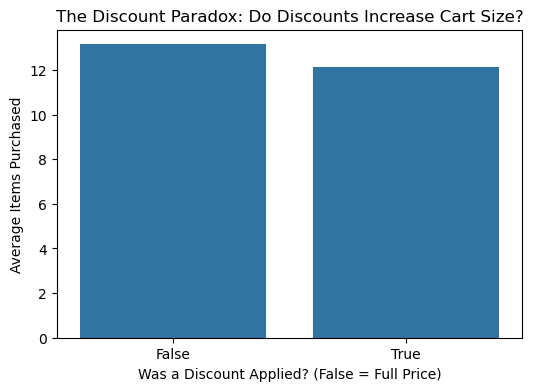

In [16]:
# Evaluating the actual effectiveness of offering discounts.

items_discount = df_clean.groupby('Discount Applied')['Items Purchased'].mean().reset_index()
print("Average Items Purchased")
display(items_discount.round(1))

discount_sat = pd.crosstab(df_clean['Discount Applied'], df_clean['Satisfaction Level'], normalize='index') * 100
print("\n Are Discounted Customers Happier? (%)")
display(discount_sat.round(1))

plt.figure(figsize=(6, 4))
sns.barplot(data=items_discount, x='Discount Applied', y='Items Purchased')

plt.title('The Discount Paradox: Do Discounts Increase Cart Size?')
plt.ylabel('Average Items Purchased')
plt.xlabel('Was a Discount Applied? (False = Full Price)')
plt.show()